In [1]:
include("../module/theory_ridgeless.jl")
using CairoMakie
using HDF5

critical tau: 2.0
  7.124624 seconds (5.99 M allocations: 1.070 GiB, 34.60% gc time)
 34.335832 seconds (28.74 M allocations: 5.137 GiB, 22.76% gc time)


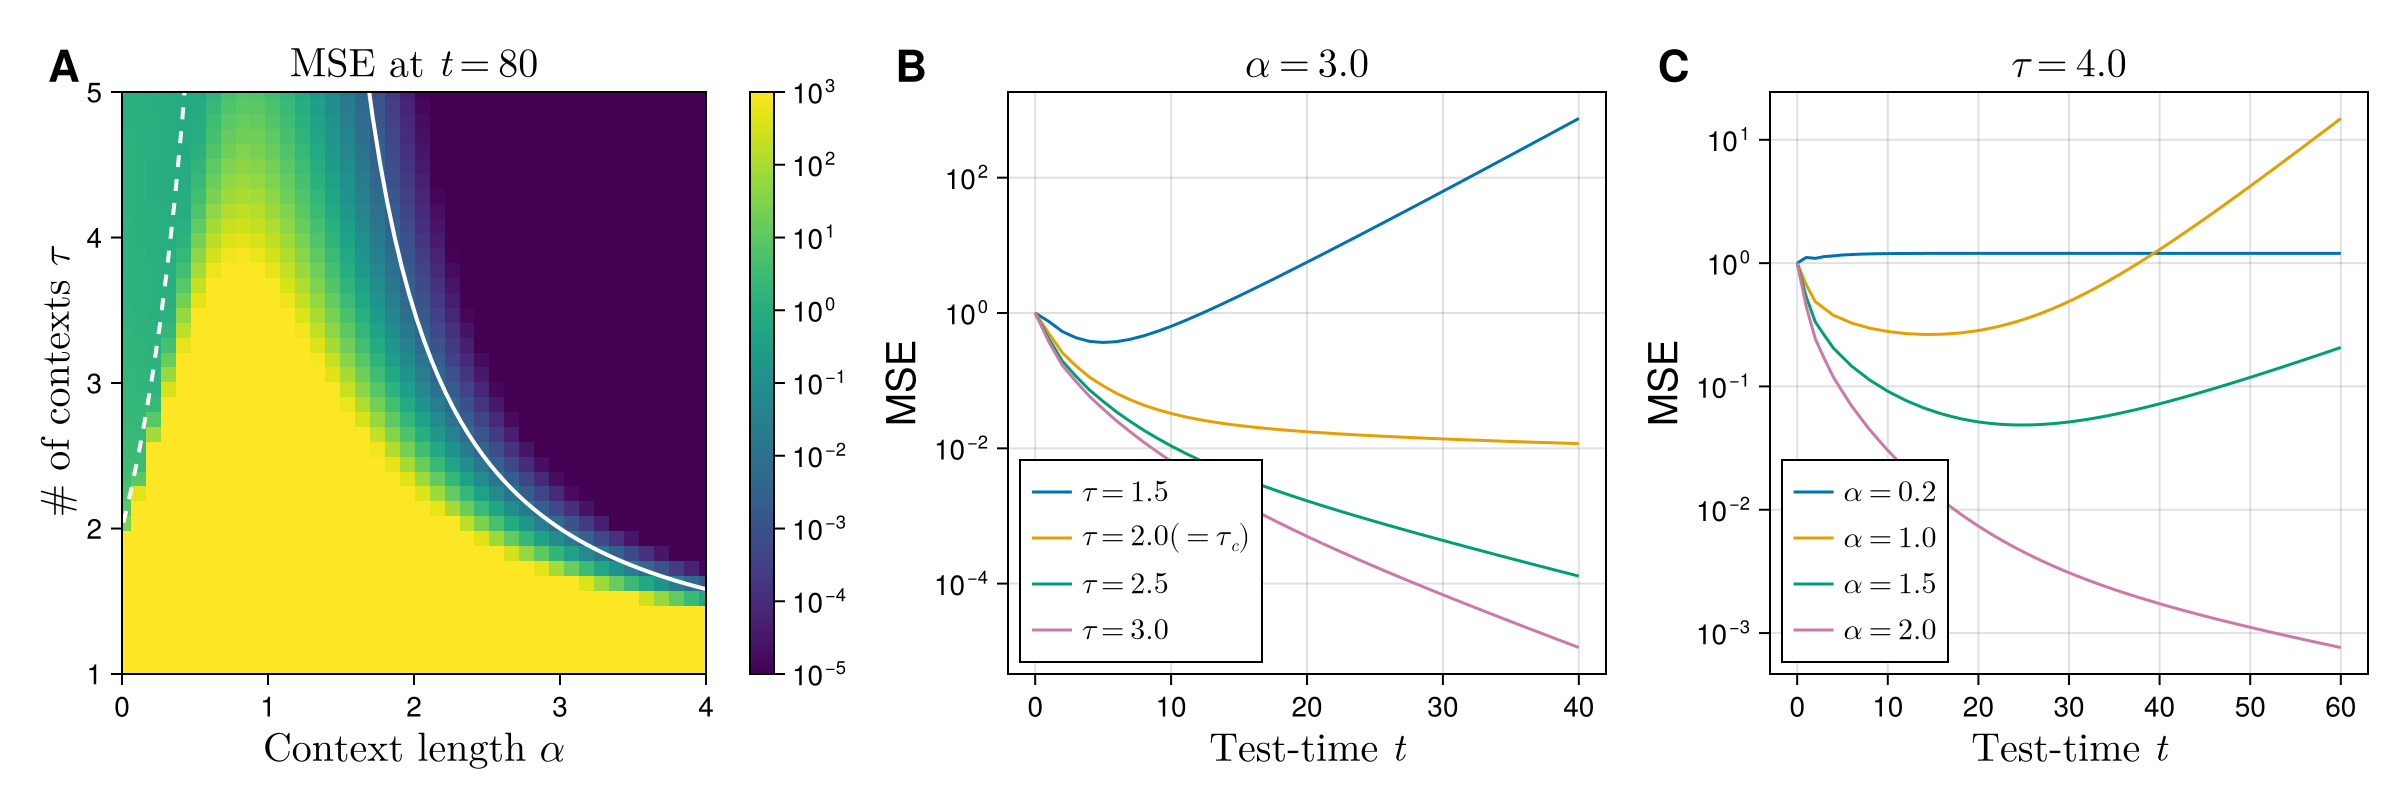

CairoMakie.Screen{PDF}


In [ ]:
alphas_trial, taus_trial, errors_at_fixed_t, t_max, sigma, alphas_critical, taus_critical =
    h5open("data/phase_diagram_theory.h5", "r") do file
        (
            read(file, "alphas_trial"),
            read(file, "taus_trial"),
            read(file, "errors_at_fixed_t"),
            read(file, "t_max"),
            read(file, "sigma"),
            read(file, "alphas"),
            read(file, "taus_critical"),
        )
    end
t_max = t_max isa AbstractArray && ndims(t_max) == 0 ? Int(t_max[]) : Int(t_max)
sigma = sigma isa AbstractArray && ndims(sigma) == 0 ? Float64(sigma[]) : Float64(sigma)


# fig1
alpha_fixed = 3.0
taus = [1.5, 2.0, 2.5, 3.0]
t_max_1 = 40
errors_1 = zeros(length(taus), t_max_1 + 1)
println("critical tau: ", tau_c(alpha_fixed, sigma))

@time for (i, tau) in enumerate(taus)
    Et, _, _, _ = theory_Et_direct(alpha_fixed, tau, sigma, t_max_1; prec=1024)
    errors_1[i, :] .= Float64.(Et)
end


# fig2
tau = 4.0
alphas_fig2 = [0.2, 1.0, 1.5, 2.0]
t_max_2 = 60
errors_2 = zeros(length(alphas_fig2), t_max_2 + 1)


@time for (i, alpha) in enumerate(alphas_fig2)
    Et, _, _, _ = theory_Et_direct(alpha, tau, sigma, t_max_2; prec=1024)
    errors_2[i, :] .= Float64.(Et)
end



fig = Figure(size = (1200, 400))

ax = Axis(fig[1, 1], xlabel=L"Context length $\alpha$", ylabel=L"# of contexts $\tau$", limits=(0.0, 4.0, 1.0, 5.0), title = L"MSE at $t =$%$(t_max)",
        titlesize=20, ylabelsize=20, xlabelsize=20, aspect=DataAspect())
hm = heatmap!(ax, alphas_trial, taus_trial, errors_at_fixed_t, colorscale=log10,
            colorrange=(10^-5, 10^3), )
Colorbar(fig[1, 2], hm)
let αc = Float64.(alphas_critical), τc = Float64.(taus_critical)
    n = length(αc)
    if n > 0
        j = searchsortedfirst(αc, 1.0)
        τ1 = if j == 1
            τc[1]
        elseif j > n
            τc[end]
        elseif αc[j] == 1.0
            τc[j]
        else
            a0, a1 = αc[j-1], αc[j]
            τc[j-1] + (1.0 - a0) / (a1 - a0) * (τc[j] - τc[j-1])
        end
        has_below = any(<(1.0), αc)
        has_above = any(>=(1.0), αc)
        if has_below
            idx_b = findlast(<(1.0), αc)
            α_d = αc[1:idx_b]
            τ_d = τc[1:idx_b]
            if has_above
                push!(α_d, 1.0)
                push!(τ_d, τ1)
            end
            lines!(ax, α_d, τ_d, color=:white, linewidth=2, linestyle=:dash)
        end
        if has_above
            idx_a = findfirst(>=(1.0), αc)
            α_s = αc[idx_a:n]
            τ_s = τc[idx_a:n]
            if has_below && α_s[1] > 1.0
                α_s = [1.0; α_s]
                τ_s = [τ1; τ_s]
            end
            lines!(ax, α_s, τ_s, color=:white, linewidth=2)
        end
    end
end
Label(fig[1, 1, TopLeft()], "A"; font=:bold, fontsize=22, halign=:left, valign=:top, padding=(8, 0, 0, 4))

# fig1
ax1 = Axis(fig[1, 3], xlabel=L"Test-time $t$", yscale = log10, title=L"$\alpha = %$(alpha_fixed)$",
        ylabel="MSE", xlabelsize=20, ylabelsize=20, titlesize=20)   
for (i, tau) in enumerate(taus)
    if tau != 2.0
        lines!(ax1, 0:t_max_1, errors_1[i, :], label=L"\tau = %$(tau)")
    else
        lines!(ax1, 0:t_max_1, errors_1[i, :], label=L"\tau = %$(tau) (= \tau_c)")
    end

end
axislegend(ax1, merge=true, labelsize=15, position=:lb)
Label(fig[1, 3, TopLeft()], "B"; font=:bold, fontsize=22, halign=:left, valign=:top, padding=(8, 0, 0, 4))

# fig2
ax2 = Axis(fig[1, 4], xlabel=L"Test-time $t$", yscale = log10, title=L"$\tau = %$(tau)$",
        ylabel="MSE", xlabelsize=20, ylabelsize=20, titlesize=20)
for (i, alpha) in enumerate(alphas_fig2)
    lines!(ax2, 0:t_max_2, errors_2[i, :], label=L"\alpha = %$(alpha)")
end
axislegend(ax2, merge=true, labelsize=15, position=:lb)
Label(fig[1, 4, TopLeft()], "C"; font=:bold, fontsize=22, halign=:left, valign=:top, padding=(8, 0, 0, 4))

display(fig)

save("phase_diagram.pdf", fig)